In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from utils import ols, mse, rmse, mae, r_squared, adjusted_r_squared

In [ ]:
seed = 46
sns.set_theme(style='darkgrid')
df = sns.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


### Encode Categorical Data
Machine learning algorithms require numerical input. Here we encode our categorical variables into numeric formats using pandas `cat.codes` and One-Hot Encoding (`get_dummies`).

In [12]:
df['sex'] = df['sex'].cat.codes
df['smoker'] = df['smoker'].cat.codes
df['time'] = df['time'].cat.codes
df = pd.get_dummies(data=df, columns=['day'])

# Split and Standardize Data
To properly evaluate our model and tune our hyperparameters without data leakage, we split our data into three sets: Training (60%), Validation (20%), and Test (20%). 
We also apply `StandardScaler` to ensure all features are on the same scale, which is a strict requirement for regularized models like Lasso.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def produce_training_data(df):
  X = df.drop(columns=['tip'])
  y = df['tip'].to_numpy()

  X_train, X_, y_train, y_ = train_test_split(X, y, test_size=0.4, random_state=seed)
  X_test, X_validate, y_test, y_validate = train_test_split(X_, y_, test_size=0.5, random_state=seed)

  scaler = StandardScaler()
  X_train_standard = scaler.fit_transform(X_train)
  X_validate_scaled = scaler.transform(X_validate)

  assert X_train_standard.shape == X_train.shape, "Standardized X_train shape does not match X_train's shape"
  assert X_validate_scaled.shape == X_validate.shape, "Standardized X_train shape does not match X_train's shape"
  assert X_train.shape[0] == y_train.shape[0], "X train's shape does not match the y train's shape"


  X_train_standard = np.concat((np.ones(X_train_standard.shape[0]).reshape(-1, 1), X_train_standard), axis=1)
  X_validate_scaled = np.concat((np.ones(X_validate_scaled.shape[0]).reshape(-1, 1), X_validate_scaled), axis=1)

  return X_train_standard, X_validate_scaled, y_train, y_validate


In [14]:
def highlighter(res_df):
    def highlight_single_cell(x):
        color_df = pd.DataFrame('', index=x.index, columns=x.columns)
        mask = res_df.iloc[1:][['MSE', 'RMSE', 'MAE']].reset_index(drop=True) < res_df.iloc[:-1][['MSE', 'RMSE', 'MAE']].reset_index(drop=True)
        mask.index += 1
        color_df[mask] = 'background-color: green'

        mask = res_df.iloc[1:][['R2', 'Adjusted_R2']].reset_index(drop=True) > res_df.iloc[:-1][['R2', 'Adjusted_R2']].reset_index(drop=True)
        mask.index += 1
        color_df[mask] = 'background-color: green'
        return color_df
    return highlight_single_cell

# Goal: Feature Selection via Sequential Evaluation
In this approach, we iteratively add features to our linear regression model one by one. 
For each iteration, we train the model and evaluate it on the validation set using several metrics:
- **Error Metrics**: MSE, RMSE, and MAE to measure the magnitude of our prediction errors.
- **R-squared ($R^2$)**: To measure the proportion of variance in the tip explained by the model.
- **Adjusted R-squared**: This is our primary metric for this notebook. Unlike standard $R^2$ (which can artificially inflate as you add features), Adjusted $R^2$ penalizes the addition of useless features. This makes it the perfect mathematical tool for feature selection.

In [15]:
X_train, X_validate, y_train, y_validate = produce_training_data(df)

def compare_features_in_model(all_features):
    features = []
    results = []
    feature_cols = df.drop(columns=['tip']).columns.tolist()

    for feature in all_features:
        features.append(feature)
        cols_idx = [feature_cols.index(f) + 1 for f in features]  # +1 for intercept col
        cols_idx = [0] + cols_idx  # prepend intercept

        X_train_new = X_train[:, cols_idx]
        X_validate_new = X_validate[:, cols_idx]

        weights = ols(X_train_new, y_train)
        pred_ols = X_validate_new @ weights

        results.append({
            "MSE": mse(y_validate, pred_ols),
            "RMSE": rmse(y_validate, pred_ols),
            "MAE": mae(y_validate, pred_ols),
            "R2": r_squared(y_validate, pred_ols),
            "Adjusted_R2": adjusted_r_squared(y_validate, pred_ols, len(features)),
            "Features": " | ".join(features[::-1]),
        })

    res_df = pd.DataFrame(results)
    styled_df = res_df.style.apply(highlighter(res_df), axis=None)
    return res_df, styled_df


all_features = df.columns.drop(['tip'])
res_df, styled_df = compare_features_in_model(all_features)
styled_df

# Adjusted R2 have it's highest value when "total_bill" is the only feature at learning.

,MSE,RMSE,MAE,R2,Adjusted_R2,Features
0,0.702875,0.838377,0.632559,0.372573,0.359223,total_bill
1,0.717085,0.846808,0.652104,0.359889,0.332058,sex | total_bill
2,0.712025,0.843815,0.652193,0.364406,0.322033,smoker | sex | total_bill
3,0.758034,0.870652,0.658335,0.323335,0.261820,time | smoker | sex | total_bill
4,0.751236,0.866739,0.653895,0.329403,0.251427,size | time | smoker | sex | total_bill
5,0.754354,0.868536,0.649571,0.326620,0.230423,day_Thur | size | time | smoker | sex | total_bill
6,0.754096,0.868387,0.648953,0.326851,0.211923,day_Fri | day_Thur | size | time | smoker | sex | total_bill
7,0.788523,0.887988,0.668521,0.296118,0.155342,day_Sat | day_Fri | day_Thur | size | time | smoker | sex | total_bill
8,0.791470,0.889646,0.668134,0.293488,0.130447,day_Sun | day_Sat | day_Fri | day_Thur | size | time | smoker | sex | total_bill


[Text(0.5, 0, 'Model Complexity'), Text(0.5, 1.0, 'Error')]

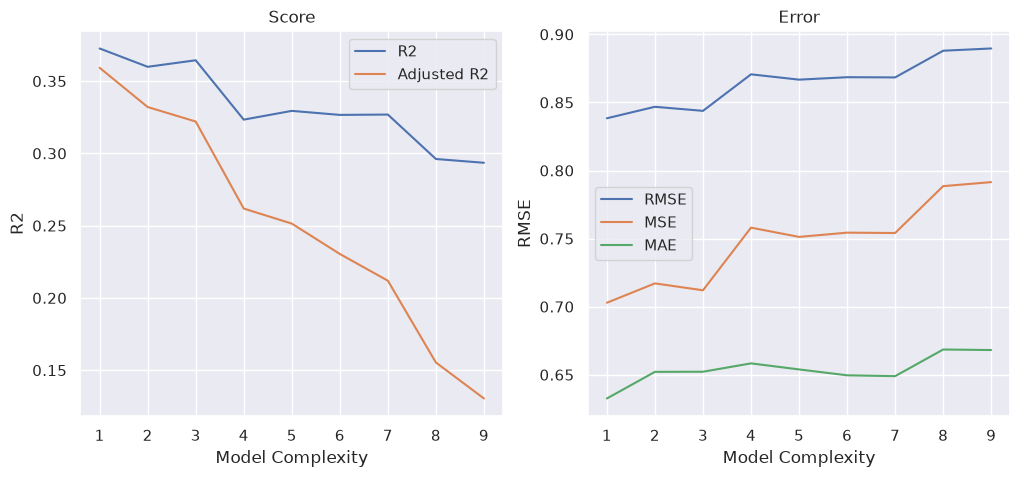

In [16]:
model_complexity = [i + 1 for i in range(len(all_features))]

fig, (ax1 , ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.lineplot(x=model_complexity, y=res_df['R2'], ax=ax1, label='R2')
sns.lineplot(x=model_complexity, y=res_df['Adjusted_R2'], ax=ax1, label='Adjusted R2')
ax1.set(xlabel="Model Complexity", title='Score')

sns.lineplot(x=model_complexity, y=res_df['RMSE'], ax=ax2, label='RMSE')
sns.lineplot(x=model_complexity, y=res_df['MSE'], ax=ax2, label='MSE')
sns.lineplot(x=model_complexity, y=res_df['MAE'], ax=ax2, label='MAE')
ax2.set(xlabel='Model Complexity', title='Error')

### Observations
- The **Adjusted $R^2$** score reaches its absolute peak when `total_bill` is the *only* feature in the model.
- As we add more features, the model complexity increases, but the performance actually degrades. Both $R^2$ and Adjusted $R^2$ decrease, and the overall error metrics (like MSE and RMSE) begin to rise. This indicates that the additional features are introducing noise rather than valuable predictive signal.

### Final Conclusion
Our sequential evaluation perfectly aligns with our visual findings from Notebook 3 and our Lasso results from Notebook 4: `total_bill` is the only feature carrying meaningful predictive power for the tip amount. 

Adding `sex`, `smoker`, `day`, `time`, or even `size` strictly decreases the model's Adjusted $R^2$ on validation data. Therefore, we will confidently drop all features except `total_bill` to build a simple, robust final model.